[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/microscopy-processing/N2N-REO/blob/main/N2N-EO.ipynb)

# N2N-EO (Noise2Noise Even Odd) tomogram denoising

## Packages

In [1]:
# pip install mrcfile
import mrcfile

In [2]:
# pip install numpy
import numpy as np

In [3]:
# pip install tqdm ipywidgets
from tqdm.notebook import tqdm

In [4]:
# pip install matplotlib
import matplotlib.pyplot as plt

In [5]:
# pip install opencv-python
import cv2

In [6]:
import json

In [7]:
# pip install tensorflow

In [8]:
# pip install cryoCARE --no-deps

In [9]:
# pip install csbdeep

In [10]:
# pip install gdown
import gdown

## Download a noisy tomogram

In [11]:
#url="https://drive.google.com/file/d/1UtFnrgTj0JE0wF3GfPNF8BBWat83j0U_/view?usp=drive_link
url="https://drive.google.com/file/d/1DZzmeJtso8woza4bPgQfUezBnTZrufuL/view?usp=sharing"
gdown.download(url, output="noisy_vol.mrc", quiet=False, use_cookies=False)

Downloading...
From: https://drive.google.com/uc?id=1DZzmeJtso8woza4bPgQfUezBnTZrufuL
To: /home/vruiz/repos/N2N-REO/noisy_vol.mrc
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 56.0M/56.0M [00:00<00:00, 58.2MB/s]


'noisy_vol.mrc'

In [12]:
!ls -l noisy_vol.mrc

-rw------- 1 vruiz vruiz 56001024 jun 18 13:19 noisy_vol.mrc


In [13]:
X = mrcfile.open("noisy_vol.mrc").data

In [14]:
X.shape

(56, 500, 500)

## Split the tomogram in even and odd axial slices

In [15]:
even_vol = X[0::2,:,:]
with mrcfile.new("even.mrc", overwrite=True) as mrc:
    mrc.set_data(even_vol)
    mrc.data

In [16]:
even_vol.shape

(28, 500, 500)

In [17]:
!ls -l "even.mrc"

-rw-r--r-- 1 vruiz vruiz 28001024 jun 19 00:00 even.mrc


In [18]:
odd_vol = X[1::2,:,:]
with mrcfile.new("odd.mrc", overwrite=True) as mrc:
    mrc.set_data(odd_vol)
    mrc.data
    mrc.data

In [19]:
odd_vol.shape

(28, 500, 500)

In [20]:
!ls -l "odd.mrc"

-rw-r--r-- 1 vruiz vruiz 28001024 jun 19 00:00 odd.mrc


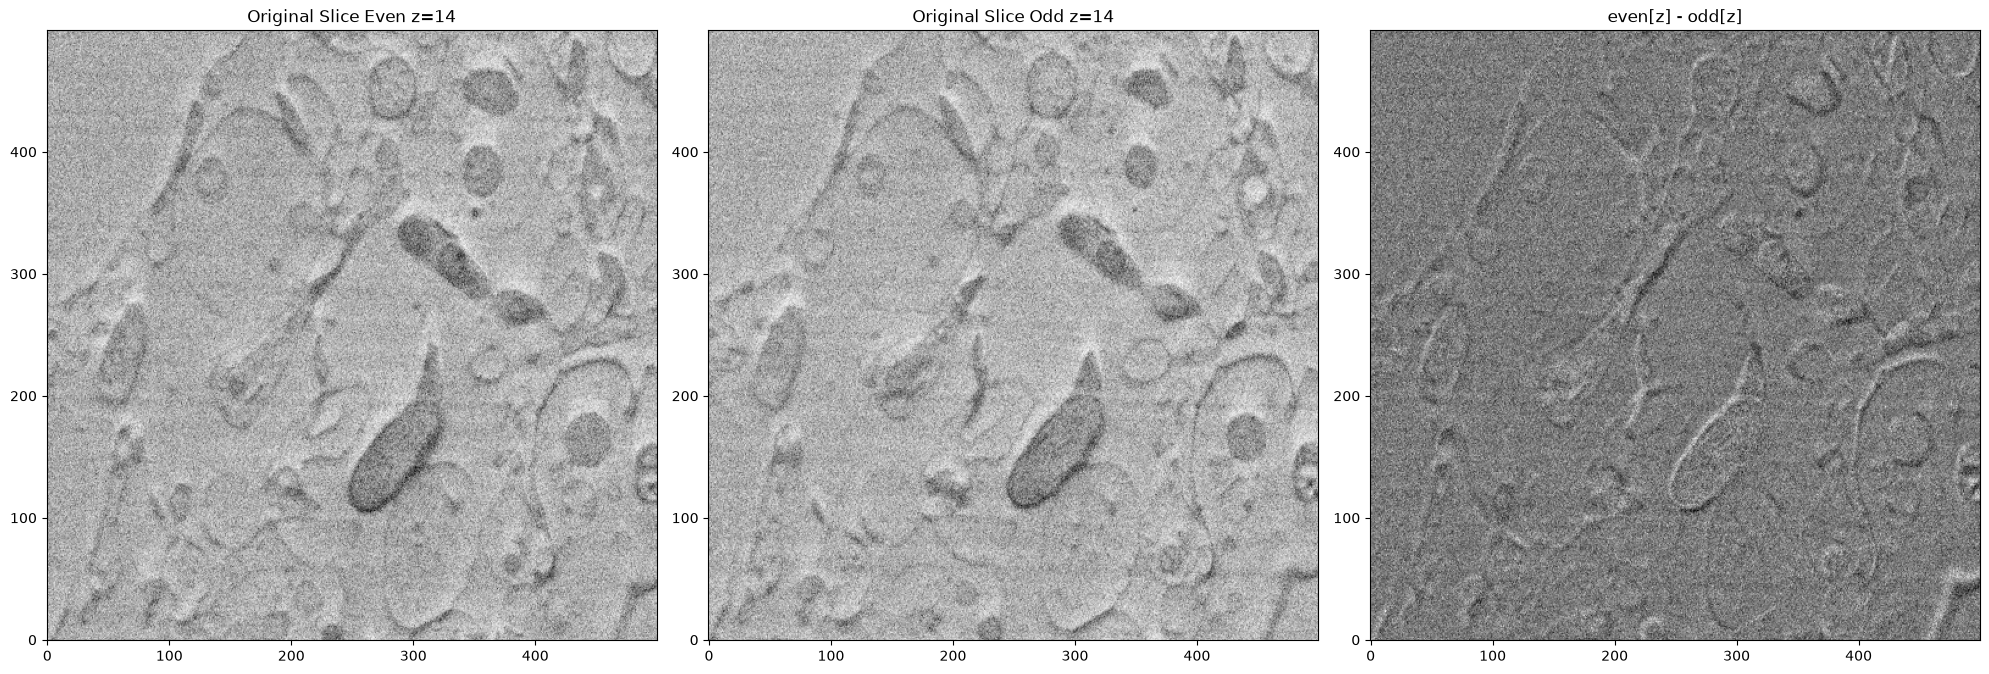

In [21]:
slice_idx = even_vol.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(20, 20))

im1 = axes[0].imshow(even_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[0].set_title(f'Original Slice Even z={slice_idx}')
axes[0].grid(False)

im2 = axes[1].imshow(odd_vol[slice_idx, ...].T, cmap='gray', origin='lower')
axes[1].set_title(f'Original Slice Odd z={slice_idx}')
axes[1].grid(False)

im3 = axes[2].imshow((even_vol[slice_idx, ...].T - odd_vol[slice_idx, ...].T + 128).astype(np.int16), cmap='gray', origin='lower')
axes[2].set_title(f'even[z] - odd[z]')
axes[2].grid(False)

plt.tight_layout()
plt.show()

# Denoising

In [22]:
_ = {
    "even": ["even.mrc"],
    "odd": ["odd.mrc"],
    "mask": [""],
    "patch_shape": [8, 8, 8], # <- Be careful here: in this example the tomogram is very small and the patch shape must be also small
    "num_slices": 800,
    "split": 0.9,
    "tilt_axis": "Y",
    "n_normalization_samples": 200,
    "path": "./data_EO",
    "overwrite": "True"  
}

with open("train_data_config__EO.json", 'w') as f:
    json.dump(_, f, indent=4)

In [23]:
%%bash
cryoCARE_extract_train_data.py --conf train_data_config__EO.json

I0000 00:00:1781820043.521222    6336 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781820043.521420    6336 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781820043.771224    6336 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781820045.531747    6336 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Computing normalization parameters:


100%|██████████| 200/200 [00:00<00:00, 11120.61it/s]


In [24]:
%%writefile train_config__EO.json
{
  "train_data": "./data_EO",
  "epochs": 50,
  "steps_per_epoch": 200,
  "batch_size": 16,
  "unet_kern_size": 3,
  "unet_n_depth": 3,
  "unet_n_first": 16,
  "learning_rate": 0.0004,
  "model_name": "model_EO",
  "path": "./",
  "gpu_id": [0]
}

Overwriting train_config__EO.json


In [25]:
%%bash
cryoCARE_train.py --conf train_config__EO.json

I0000 00:00:1781820047.575193    6378 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781820047.575372    6378 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781820047.616779    6378 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781820048.830270    6378 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Looking for GPU with ID: 0
0 1
1 8
2 8
3 8
4 1
Epoch 1/50


E0000 00:00:1781820052.656028    6378 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1.1409 - mae: 0.8426 - mse: 1.1409

/home/vruiz/envs/N2N-REO/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


...

W0000 00:00:1781820282.844492    6378 dataset.cc:997] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.6409 - mae: 0.6382 - mse: 0.6409 - val_loss: 0.9261 - val_mae: 0.7623 - val_mse: 0.9261 - learning_rate: 5.0000e-05
Epoch 43/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.6396 - mae: 0.6375 - mse: 0.6396 - val_loss: 0.9322 - val_mae: 0.7638 - val_mse: 0.9322 - learning_rate: 5.0000e-05
Epoch 44/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.6387 - mae: 0.6373 - mse: 0.6387 - val_loss: 0.9116 - val_mae: 0.7570 - val_mse: 0.9116 - learning_rate: 5.0000e-05
Epoch 45/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.6375 - mae: 0.6364 - mse: 0.6375 - val_loss: 0.9157 - val_mae: 0.7567 - val_mse: 0.9157 - learning_rate: 5.0000e-05
Epoch 46/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.6367 - mae: 0.6363 - mse: 0.6367 - val_loss: 0.9240 - val_mae: 0.7601 - val_mse: 0.9240 - learning_rate: 5.0000e-05
Epoch 47/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.6360 - mae: 0.6357 - mse: 0.6360 - val_loss: 0.9

W0000 00:00:1781820315.677393    6378 dataset.cc:997] Input of GeneratorDatasetOp::Dataset will not be optimized because the dataset does not implement the AsGraphDefInternal() method needed to apply optimizations.


200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.6357 - mae: 0.6357 - mse: 0.6357 - val_loss: 0.9259 - val_mae: 0.7604 - val_mse: 0.9259 - learning_rate: 5.0000e-05
Epoch 49/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.6339 - mae: 0.6350 - mse: 0.6339 - val_loss: 0.9306 - val_mae: 0.7626 - val_mse: 0.9306 - learning_rate: 5.0000e-05
Epoch 50/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.6316 - mae: 0.6338 - mse: 0.6316
Epoch 50: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.6324 - mae: 0.6342 - mse: 0.6324 - val_loss: 0.9246 - val_mae: 0.7596 - val_mse: 0.9246 - learning_rate: 5.0000e-05

Loading network weights from 'weights_best.h5'.


W0000 00:00:1781820327.249124    6378 generator_dataset_op.cc:113] Error occurred when finalizing GeneratorDataset iterator: FAILED_PRECONDITION: Python interpreter state is not initialized. The process may be terminated.
	 [[{{node PyFunc}}]]


In [26]:
_ = {
    "path": "./model_EO.tar.gz",
    "even": ["noisy_vol.mrc"], 
    "odd": ["noisy_vol.mrc"],
    "n_tiles": [1,1,1],
    "output": "denoised_vol_EO",
    "overwrite": "True",
    "gpu_id": [0]
}

with open("predict_config__EO.json", 'w') as f:
    json.dump(_, f, indent=4)

In [27]:
%%bash
cryoCARE_predict.py --conf predict_config__EO.json || true

I0000 00:00:1781820327.951273   12513 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781820327.951458   12513 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781820327.993885   12513 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781820329.301033   12513 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Looking for GPU with ID: 0
Loading network weights from 'weights_best.h5'.
(56, 504, 504, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
['NEWSTACK: Images copied                                  3-Oct-25  17:07:14     '
 'NEWSTACK: Images copied                                 12-Jun-26  15:28:28     '
 'egrate=1\r\nFrameTime=51.1672\r\n\r\n[EScan]\r\nScan=\x00\x00\x00\x00\x00\x00\x00\x00OInterna\x00\x00\x00\x00\x00\x00\x00\x00Oe\r\nDwell=5'
 '-007\r\nPixelWidth=6.74479e-009\r\nPixelHeight=6.74479e-009\r\nHorFieldsize=2.072e-005'
 '\nVerFieldsize=1.38133e-005\r\nFrameTime=51.1672\r\nLineTime=0.024984\r\nMainslock=Off\r'
 'LineIntegration=16\r\nScanInterlacing=1\r\n\r\n[Stage]\r\nStageX=0.00371587\r\nStageY=0.00'
 '293\r\nStageZ=0.00403778\r\nStageR=-1.22169\r\nStageT=0.122173\r\nStageTb=0\r\nSpecTilt=\r\n'
 'orkingDistance=0.00403779\r\nActiveStage=Bulk\r\n\r\n[Image]\r\nDigitalContrast=1\r\nDigit'
 'cryoCARE                                                1

In [28]:
!ls -l denoised_vol_EO/noisy_vol.mrc

-rw-r--r-- 1 vruiz vruiz 56001024 jun 19 00:05 denoised_vol_EO/noisy_vol.mrc


In [29]:
Y = mrcfile.read("denoised_vol_EO/noisy_vol.mrc").astype(np.int16)

In [30]:
X.shape

(56, 500, 500)

In [31]:
Y.shape

(56, 500, 500)

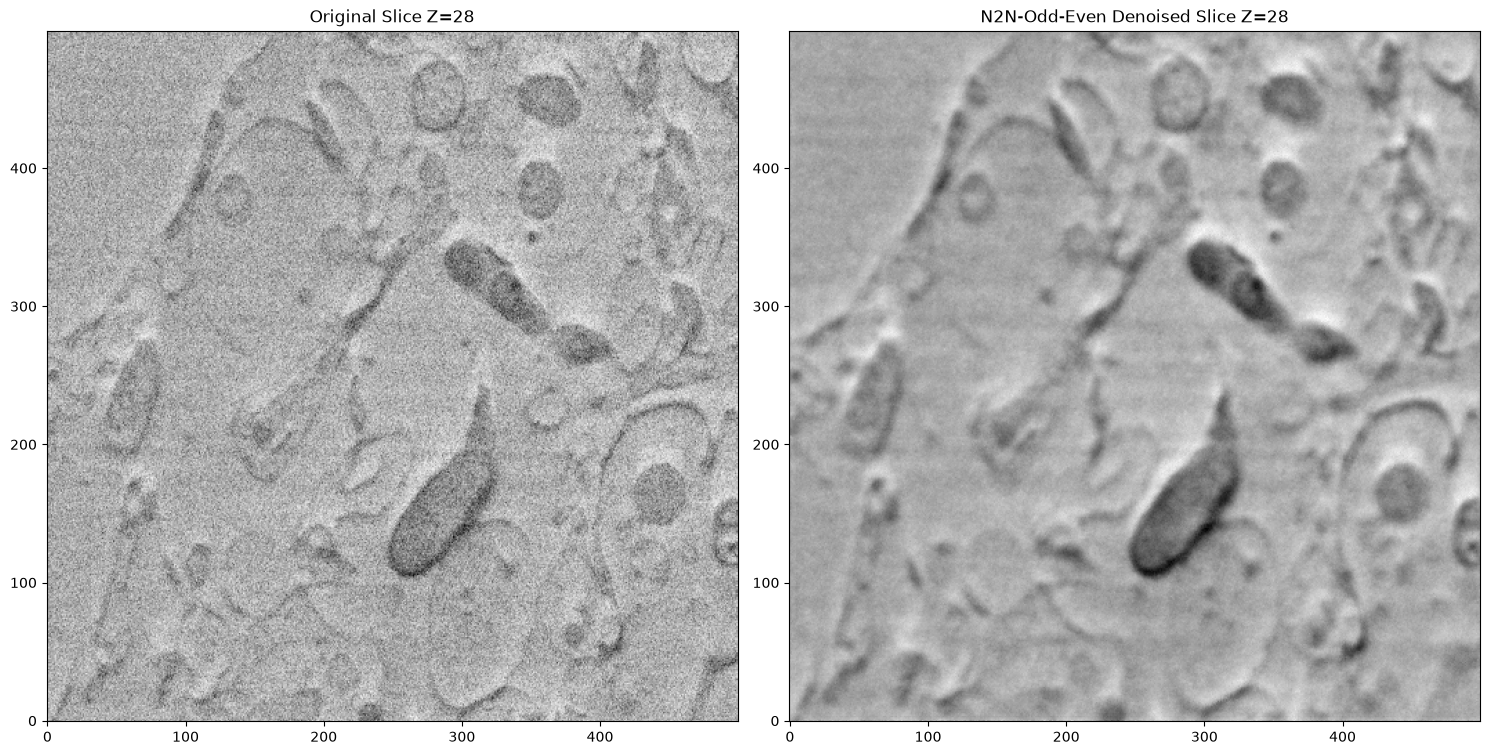

In [32]:
slice_idx = X.shape[0] // 2

fig, axes = plt.subplots(1, 2, figsize=(15, 15))

# Plot a original slice
im1 = axes[0].imshow(X[slice_idx, :, :].T, cmap='gray', origin='lower')
axes[0].set_title(f'Original Slice Z={slice_idx}')
axes[0].grid(False)

# Plot a denoised slice
im2 = axes[1].imshow(Y[slice_idx, :, :].T, cmap='gray', origin='lower')
axes[1].set_title(f'N2N-Odd-Even Denoised Slice Z={slice_idx}')
axes[1].grid(False)

plt.tight_layout()
plt.show()